# Name: Prathamesh Balaji Patil
# Roll: 11
# Div: TY A(AIML)
#Experiment No.5


# Multiclass Classification using Logistic Regression

## Experiment Objective
To understand and implement **Logistic Regression for Multiclass Classification** using a **simple manually created dataset**.

### Example Use Case
Predict **Student Performance Level** (Low, Medium, High) based on:
- Study Hours
- Attendance Percentage



## Step 1: Import Required Libraries


In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report



## Step 2: Create a Simple Multiclass Dataset
Target Variable:
- 0 → Low Performance
- 1 → Medium Performance
- 2 → High Performance


In [30]:

data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,9,10],
    'Attendance': [50,55,60,65,70,75,80,85,90,95],
    'Performance': [0,0,0,1,1,1,2,2,2,2]
}

df = pd.DataFrame(data)
df


,Study_Hours,Attendance,Performance
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,1
4,5,70,1
5,6,75,1
6,7,80,2
7,8,85,2
8,9,90,2
9,10,95,2



## Step 3: Explore the Dataset


In [31]:
df.shape

(10, 3)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Performance  10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [33]:
df.describe()

,Study_Hours,Attendance,Performance
count,10.00000,10.000000,10.000000
mean,5.50000,72.500000,1.100000
std,3.02765,15.138252,0.875595
min,1.00000,50.000000,0.000000
25%,3.25000,61.250000,0.250000
50%,5.50000,72.500000,1.000000
75%,7.75000,83.750000,2.000000
max,10.00000,95.000000,2.000000



## Step 4: Split Features and Target


In [34]:
X = df[['Study_Hours', 'Attendance']]
y = df['Performance']


## Step 5: Train-Test Split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 6: Create and Train Logistic Regression Model


In [36]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')


## Step 7: Model Prediction and Evaluation


In [37]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2




## Step 8: Visualization


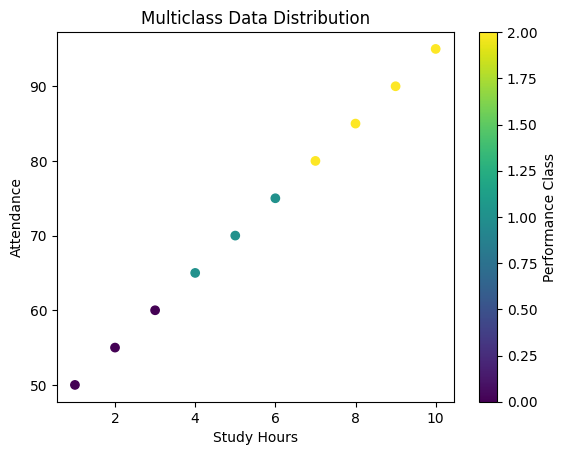

In [38]:
plt.scatter(df['Study_Hours'], df['Attendance'], c=df['Performance'], cmap='viridis')
plt.xlabel('Study Hours')
plt.ylabel('Attendance')
plt.title('Multiclass Data Distribution')
plt.colorbar(label='Performance Class')
plt.show()


## Step 9: Prediction Using User Input


In [39]:
study_hours = float(input("Enter study hours: "))
attendance = float(input("Enter attendance percentage: "))

new_data = [[study_hours, attendance]]
prediction = model.predict(new_data)

labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Predicted Performance Level:", labels[prediction[0]])

Enter study hours: 5
Enter attendance percentage: 85
Predicted Performance Level: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
import pickle

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pickle

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    ))
])

# Train the complete pipeline
final_model.fit(X_train, y_train)

# Save model
pickle.dump(final_model, open("MCModel.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



## Conclusion
Logistic Regression can be extended for multiclass classification using the multinomial approach.


**Flask Code**

Save this file with 'app.py'

In [ ]:
from flask import Flask, render_template, request
import pickle

# Create Flask application

app = Flask(__name__)

# Load the trained machine learning model

with open("MCModel.pkl", "rb") as file:
    model = pickle.load(file)

# Home Page

@app.route("/")
def home():
    return render_template("index.html")

# Prediction Page

@app.route("/predict", methods=["POST"])
def predict():

        # Get input values from HTML form
        study_hours = float(request.form["study_hours"])
        attendance = float(request.form["attendance"])

        # Validate study hours
        if study_hours < 0:
            return render_template(
                "index.html",
                prediction_text="Study hours cannot be negative."
            )

        # Validate attendance
        if attendance < 0 or attendance > 100:
            return render_template(
                "index.html",
                prediction_text="Attendance must be between 0 and 100."
            )

        # Prepare data for prediction
        input_data = [[study_hours, attendance]]

        # Make prediction
        prediction = model.predict(input_data)

        # Convert prediction number into performance category
        performance_labels = {
            0: "Low",
            1: "Medium",
            2: "High"
        }

        # Get final result
        result = performance_labels.get(
            int(prediction[0]),
            "Unknown Performance"
        )

        # Display result on website
        return render_template(
            "index.html",
            prediction_text=f"Predicted Performance Level: {result}"
        )


# Run Flask Application

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file with 'index.html'

In [ ]:
<!DOCTYPE html>

<html lang="en">

<head>


<meta charset="UTF-8">

<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Student Performance Predictor</title>


<style>

    * {
        margin: 0;
        padding: 0;
        box-sizing: border-box;
        font-family: Arial, Helvetica, sans-serif;
    }


    body {
        min-height: 100vh;

        display: flex;
        justify-content: center;
        align-items: center;

        background: linear-gradient(
            135deg,
            #dbeafe,
            #eff6ff,
            #e0f2fe
        );

        padding: 20px;
    }


    .container {

        width: 500px;
        max-width: 100%;

        background: white;

        padding: 40px;

        border-radius: 20px;

        box-shadow:
            0px 15px 35px
            rgba(0, 0, 0, 0.15);

    }


    .icon {

        width: 70px;
        height: 70px;

        background: #1565c0;

        border-radius: 50%;

        display: flex;

        justify-content: center;
        align-items: center;

        margin: auto;

        font-size: 32px;

        color: white;

    }


    h1 {

        text-align: center;

        color: #1565c0;

        margin-top: 18px;

        font-size: 28px;

    }


    .subtitle {

        text-align: center;

        color: #666;

        margin-top: 10px;

        margin-bottom: 30px;

        font-size: 15px;

    }


    label {

        display: block;

        margin-top: 18px;

        margin-bottom: 8px;

        color: #333;

        font-weight: bold;

    }


    input {

        width: 100%;

        padding: 14px;

        border: 1px solid #d1d5db;

        border-radius: 10px;

        font-size: 16px;

        transition: 0.3s;

    }


    input:focus {

        outline: none;

        border-color: #1565c0;

        box-shadow:
            0 0 0 3px
            rgba(21, 101, 192, 0.12);

    }


    .input-info {

        font-size: 12px;

        color: #777;

        margin-top: 6px;

    }


    button {

        width: 100%;

        padding: 15px;

        margin-top: 30px;

        border: none;

        border-radius: 10px;

        background: #1565c0;

        color: white;

        font-size: 17px;

        font-weight: bold;

        cursor: pointer;

        transition: 0.3s;

    }


    button:hover {

        background: #0d47a1;

        transform: translateY(-2px);

    }


    .result {

        margin-top: 25px;

        padding: 18px;

        border-radius: 12px;

        text-align: center;

        background: #ecfdf5;

        border: 1px solid #bbf7d0;

        color: #166534;

        font-size: 18px;

        font-weight: bold;

    }


    footer {

        text-align: center;

        margin-top: 25px;

        color: #888;

        font-size: 12px;

    }


</style>


</head>

<body>


<div class="container">


    <div class="icon">
        🎓
    </div>


    <h1>
        Student Performance Predictor
    </h1>


    <p class="subtitle">
        Predict student performance using Machine Learning
    </p>


    <form action="/predict" method="POST">


        <!-- Study Hours -->

        <label for="study_hours">

            Study Hours

        </label>


        <input
            type="number"
            id="study_hours"
            name="study_hours"
            step="0.1"
            min="0"
            placeholder="Example: 5"
            required
        >


        <p class="input-info">

            Enter the number of hours spent studying.

        </p>


        <!-- Attendance -->

        <label for="attendance">

            Attendance Percentage

        </label>


        <input
            type="number"
            id="attendance"
            name="attendance"
            step="0.1"
            min="0"
            max="100"
            placeholder="Example: 85"
            required
        >


        <p class="input-info">

            Enter attendance percentage between 0 and 100.

        </p>


        <!-- Predict Button -->

        <button type="submit">

            Predict Performance

        </button>


    </form>


    <!-- Prediction Result -->

    {% if prediction_text %}

    <div class="result">

        {{ prediction_text }}

    </div>

    {% endif %}


    <footer>

        Machine Learning Student Performance Prediction System

    </footer>


</div>


</body>

</html>
